<a href="https://colab.research.google.com/github/misun0314/AI-Python/blob/main/AI%EC%BD%94%EB%94%A9%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"나는 파이썬 전문가이지만 조선공학 지식은 없어. 내일 대학교 4학년 학생들에게 '선박 복원성 계산(Simpson's Rule 이용) 파이썬 실습'을 가르쳐야 해.
1. 조선공학에서 복원성 계산이 왜 중요한지 비전공자 수준으로 비유를 들어 설명해 줘.
2. 학생들이 실무에서 맞닥뜨릴 만한 가상의 선체 단면 데이터(CSV) 구조를 짜줘.
3. 이 데이터를 처리하는 파이썬 코드와 함께, 학생들이 자주 막히는 부분(에러) 3가지를 짚어줘."

  폰트 설정 완료: ['NanumGothic']
  선박 복원성(Ship Stability) 이란?

  [비유] 오뚝이 장난감을 생각해보세요.
  - 오뚝이를 기울이면  -> 다시 일어나려는 힘이 생깁니다.
  - 배도 파도에 기울어질 때 -> 원래 자세로 돌아오려는 힘이 필요합니다.
  - 이 힘의 크기를 'GZ (복원 팔)' 라고 합니다.
  - GZ가 클수록  -> 안전한 배
  - GZ가 0 이하  -> 뒤집힐 위험!

  핵심 키워드:
  K  = 용골(Keel)        배의 바닥 중심점 (기준점)
  B  = 부심(Buoyancy)    물에 잠긴 체적의 무게중심
  G  = 무게중심(Gravity)  배 전체 무게가 집중된 점
  M  = 경심(Metacenter)  배가 기울었을 때 부력 방향선 교점
  GM = KM - KG           복원력의 크기 (클수록 안정)
  GZ = 복원 팔           기울어진 상태에서 복원력의 수평 거리

  STEP 1: 선박 기본 제원
  선박 길이 Lpp     : 300.0  m
  최대 형폭  B      : 19.0  m
  설계 흘수  T      : 8.0  m
  무게중심  KG      : 6.8  m
  방형계수  Cb      : 0.82  -
  해수 밀도         : 1.025  t/m3
  스테이션 수        : 11  개

  STEP 2: Simpson's Rule 계수 (SM) 생성 및 검증
  SM = [1, 4, 2, 4, 2, 4, 2, 4, 2, 4, 1]
  SM 합계 = 30  (3의 배수: True)
  [OK] 4가지 검증 모두 통과

  STEP 3: 스테이션별 반폭(Half-Breadth) — hull_sections.csv 참조
   St.     반폭 y(m)    SM        SM*y         SM*y^3
  ------------------------------------------------
     0     

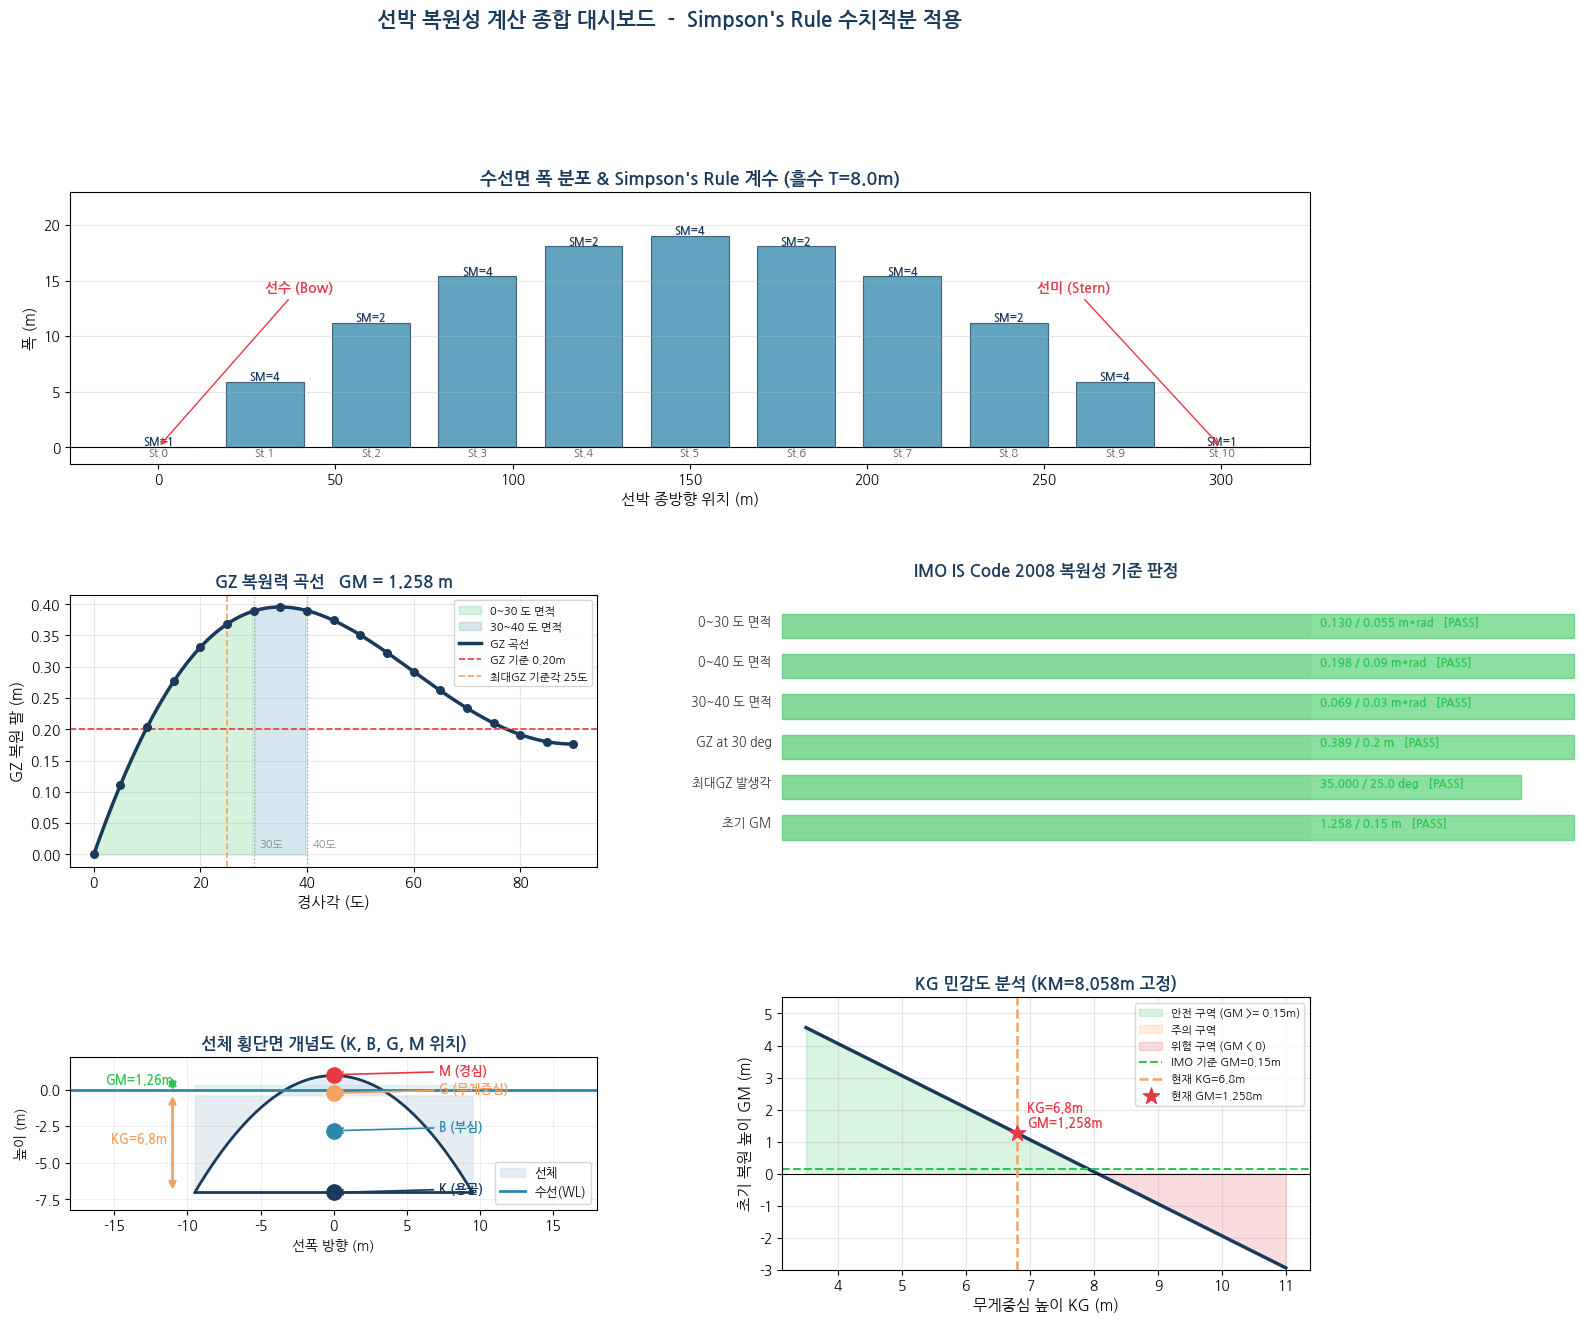

  [OK] 대시보드 저장 완료: stability_dashboard.png

  최종 계산 결과 요약
  수선면적 Aw                 : 7257.89 m2
  배수 체적 V                 : 37,392.00 m3
  배수량 Delta               : 38,326.80 ton
  수선면 관성모멘트 IT            : 145,472.97 m4
  부심 높이 KB                : 4.1676 m
  경심 반경 BM                : 3.8905 m
  경심 높이 KM                : 8.0581 m
  무게중심 KG                 : 6.8000 m
  복원 높이 GM                : 1.2581 m  <- 핵심!
  최대 GZ                   : 0.3956 m @ 35 deg
  IMO 종합 판정               : 합격


In [9]:
# =============================================================================
#  선박 복원성 계산 — Simpson's Rule 적용  [Colab 완전 호환 버전]
#  수정 사항:
#    1) 한글 폰트: Colab 환경 NanumGothic 자동 설치·적용
#    2) GZ 함수: phi=0 에서 tan(0) 나눗셈 오류 방지
#    3) np.trapz → np.trapezoid (NumPy 2.x 경고 제거)
#    4) ✅ 이모지 → 텍스트(PASS/FAIL) 로 교체 (폰트 깨짐 방지)
#    5) marker="★" → marker="*" (특수문자 오류 방지)
#    6) matplotlib 경고 제거: rcParams 한 곳에서만 설정
# =============================================================================
# [실행] Google Colab 셀에 전체 붙여넣기 후 실행
# [패키지] pip install numpy matplotlib  (Colab은 기본 설치됨)
# =============================================================================

# ── 0. 패키지 임포트 ─────────────────────────────────────────────────────────
import math, os, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm

# AUTO-INJECTED: Korean font setup for matplotlib
import os as _os
import matplotlib.font_manager as _fm
import matplotlib.pyplot as _plt
if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
    for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                  '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
        if _os.path.exists(_font):
            _fm.fontManager.addfont(_font)
_plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
del _os, _fm, _plt
# END AUTO-INJECTED Korean font setup


# ── 1. 한글 폰트 설정 (Colab / Linux / Windows 자동 감지) ───────────────────
def setup_korean_font():
    """
    환경별 한글 폰트 자동 설정
    - Colab/Linux : NanumGothic apt 설치 후 적용
    - Windows     : Malgun Gothic 적용
    - Mac         : AppleGothic 적용
    """
    system_fonts = [f.name for f in fm.fontManager.ttflist]

    if any('Nanum' in fn for fn in system_fonts):
        # 이미 설치된 경우
        matplotlib.rcParams['font.family'] = 'NanumGothic'

    elif os.name == 'nt':                        # Windows
        matplotlib.rcParams['font.family'] = 'Malgun Gothic'

    elif os.path.exists('/usr/bin/apt-get'):     # Colab / Ubuntu
        print("NanumGothic 설치 중... (최초 1회만 실행)")
        subprocess.run(
            ['apt-get', 'install', '-y', '-q', 'fonts-nanum'],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        fm._load_fontmanager(try_read_cache=False)
        matplotlib.rcParams['font.family'] = 'NanumGothic'

    else:                                        # Mac
        matplotlib.rcParams['font.family'] = 'AppleGothic'

    matplotlib.rcParams['axes.unicode_minus'] = False
    print(f"  폰트 설정 완료: {matplotlib.rcParams['font.family']}")

setup_korean_font()


# =============================================================================
# 2. 비유로 이해하는 선박 복원성
# =============================================================================
print("=" * 65)
print("  선박 복원성(Ship Stability) 이란?")
print("=" * 65)
print("""
  [비유] 오뚝이 장난감을 생각해보세요.
  - 오뚝이를 기울이면  -> 다시 일어나려는 힘이 생깁니다.
  - 배도 파도에 기울어질 때 -> 원래 자세로 돌아오려는 힘이 필요합니다.
  - 이 힘의 크기를 'GZ (복원 팔)' 라고 합니다.
  - GZ가 클수록  -> 안전한 배
  - GZ가 0 이하  -> 뒤집힐 위험!

  핵심 키워드:
  K  = 용골(Keel)        배의 바닥 중심점 (기준점)
  B  = 부심(Buoyancy)    물에 잠긴 체적의 무게중심
  G  = 무게중심(Gravity)  배 전체 무게가 집중된 점
  M  = 경심(Metacenter)  배가 기울었을 때 부력 방향선 교점
  GM = KM - KG           복원력의 크기 (클수록 안정)
  GZ = 복원 팔           기울어진 상태에서 복원력의 수평 거리
""")


# =============================================================================
# 3. 선박 기본 제원
# =============================================================================
print("=" * 65)
print("  STEP 1: 선박 기본 제원")
print("=" * 65)

Lpp             = 300.0   # 수선간 길이 (m)
B_max           = 19.0    # 최대 형폭 (m)
T               = 8.0     # 설계 흘수 (m)
KG              = 6.8     # 무게중심 높이 (m)
Cb              = 0.82    # 방형 계수
rho             = 1.025   # 해수 밀도 (t/m3)
n_stations      = 11      # 스테이션 수 (반드시 홀수!)
station_spacing = 30.0    # 스테이션 간격 (m) = Lpp / 10

for k, v, u in [
    ("선박 길이 Lpp", Lpp,  "m"),
    ("최대 형폭  B",  B_max,"m"),
    ("설계 흘수  T",  T,    "m"),
    ("무게중심  KG",  KG,   "m"),
    ("방형계수  Cb",  Cb,   "-"),
    ("해수 밀도",    rho,  "t/m3"),
    ("스테이션 수",  n_stations, "개"),
]:
    print(f"  {k:<14}: {v}  {u}")


# =============================================================================
# 4. Simpson's Rule 계수 생성 및 검증
# =============================================================================
print()
print("=" * 65)
print("  STEP 2: Simpson's Rule 계수 (SM) 생성 및 검증")
print("=" * 65)

def generate_sm(n):
    """
    1/3 Simpson's Rule 계수 생성
    패턴: 1, 4, 2, 4, 2, ..., 4, 1
    주의: n 은 반드시 홀수 (3, 5, 7, 9, 11 ...)
    """
    if n % 2 == 0:
        raise ValueError(f"스테이션 수는 홀수여야 합니다! 입력값: {n}")
    if n < 3:
        raise ValueError(f"스테이션 수는 3 이상이어야 합니다! 입력값: {n}")
    SM = [1]
    for i in range(1, n - 1):
        SM.append(4 if i % 2 == 1 else 2)
    SM.append(1)
    return SM

SM = generate_sm(n_stations)

# 4가지 검증 — 학생 실수 방지 핵심 코드
assert SM[0] == 1 and SM[-1] == 1,       "시작/끝은 반드시 1"
assert all(s in [1, 2, 4] for s in SM),  "SM 값은 1, 2, 4만 허용"
assert sum(SM) % 3 == 0,                 "SM 합계는 3의 배수"
assert len(SM) % 2 == 1,                 "SM 개수는 홀수"

print(f"  SM = {SM}")
print(f"  SM 합계 = {sum(SM)}  (3의 배수: {sum(SM) % 3 == 0})")
print("  [OK] 4가지 검증 모두 통과")


# =============================================================================
# 5. 스테이션별 반폭(Half-Breadth) 계산
# =============================================================================
print()
print("=" * 65)
print("  STEP 3: 스테이션별 반폭(Half-Breadth) — hull_sections.csv 참조")
print("=" * 65)

def half_breadth(station, draft):
    """
    각 스테이션·흘수에서의 반폭(m) — 가상 선형 모델
    실무: CAD(Rhino, Maxsurf)에서 추출한 CSV 로드 후 사용

    Parameters
    ----------
    station : int    스테이션 번호 (0=선수, 10=선미)
    draft   : float  계산 흘수 (m)

    Returns
    -------
    float  반폭 (m), 항상 0 이상
    """
    n  = Lpp / station_spacing          # 스테이션 간격 수
    sf = math.sin(math.pi * station / n)  # 종방향 형상 (정현 분포)
    wf = min(1.0, 0.4 + 0.6 * (draft / 8.0))  # 흘수 방향 형상
    hb = 9.5 * sf * wf

    # 선수부(0,1) 선미부(9,10) 추가 감소
    if station <= 1:  hb *= (0.3 + 0.7 * station)
    if station >= 9:  hb *= (0.3 + 0.7 * (10 - station))

    return max(0.0, round(hb, 4))

stations = list(range(n_stations))
half_b   = [half_breadth(st, T) for st in stations]

print(f"  {'St.':>4}  {'반폭 y(m)':>10}  {'SM':>4}  {'SM*y':>10}  {'SM*y^3':>13}")
print("  " + "-" * 48)
for st, y, sm in zip(stations, half_b, SM):
    print(f"  {st:>4}  {y:>10.4f}  {sm:>4}  {sm*y:>10.4f}  {sm*y**3:>13.4f}")


# =============================================================================
# 6. 수선면적(Aw) — Simpson's Rule 종방향 적분
# =============================================================================
print()
print("=" * 65)
print("  STEP 4: 수선면적(Aw) 계산")
print("=" * 65)
print("  공식: Aw = (2/3) * h * sum(SM * y) * 2  [좌우 대칭]")

h     = station_spacing
sum_y = sum(sm * y for sm, y in zip(SM, half_b))
Aw    = (2/3) * h * sum_y * 2

Cw_calc = Aw / (Lpp * B_max)
Cw_est  = 0.95 * Cb + 0.17 * (1 - Cb) ** (1/3)
Cw = Cw_est

print(f"  h = {h} m,  sum(SM*y) = {sum_y:.4f}")
print(f"  Aw = (2/3) * {h} * {sum_y:.4f} * 2 = {Aw:.2f} m2")
print(f"  Cw (계산) = {Cw_calc:.4f}  /  Cw (추정식) = {Cw_est:.4f}")


# =============================================================================
# 7. 배수 체적(V) 및 배수량(Delta)
# =============================================================================
print()
print("=" * 65)
print("  STEP 5: 배수 체적 및 배수량")
print("=" * 65)

volume = Lpp * B_max * T * Cb
delta  = volume * rho

print(f"  V = Lpp*B*T*Cb = {Lpp}*{B_max}*{T}*{Cb} = {volume:,.2f} m3")
print(f"  Delta = V * rho = {volume:,.2f} * {rho} = {delta:,.2f} ton")


# =============================================================================
# 8. 관성 모멘트(IT) 및 BM
# =============================================================================
print()
print("=" * 65)
print("  STEP 6: 횡관성 모멘트(IT) 및 BM 계산")
print("=" * 65)
print("  공식: IT = (2/9) * h * sum(SM * y^3) * 2")
print("        BM = IT / V")

sum_y3 = sum(sm * y**3 for sm, y in zip(SM, half_b))
IT     = (2/9) * h * sum_y3 * 2
BM     = IT / volume

print(f"  sum(SM*y^3) = {sum_y3:.4f}")
print(f"  IT = {IT:,.4f} m4")
print(f"  BM = IT / V = {IT:,.4f} / {volume:,.2f} = {BM:.4f} m")


# =============================================================================
# 9. KB — Morrish 공식
# =============================================================================
print()
print("=" * 65)
print("  STEP 7: KB 계산 (Morrish 공식)")
print("=" * 65)
print("  KB = T * (5/6 - Cb / (3 * Cw))")

KB = T * (5/6 - Cb / (3 * Cw))
print(f"  KB = {T} * (5/6 - {Cb}/(3*{Cw:.4f})) = {KB:.4f} m")


# =============================================================================
# 10. GM 계산 및 초기 복원성 판정
# =============================================================================
print()
print("=" * 65)
print("  STEP 8: GM 계산 및 초기 복원성 판정")
print("=" * 65)

KM = KB + BM
GM = KM - KG

print(f"  KM = KB + BM = {KB:.4f} + {BM:.4f} = {KM:.4f} m")
print(f"  GM = KM - KG = {KM:.4f} - {KG:.4f} = {GM:.4f} m")
print()

if GM >= 0.15:
    gm_status = "[OK] 합격  (IMO 기준 GM >= 0.15m 만족)"
elif GM > 0:
    gm_status = "[주의] GM > 0 이나 IMO 기준 미달"
else:
    gm_status = "[위험] GM <= 0, 전복 위험!"

print(f"  GM 판정: {gm_status}")


# =============================================================================
# 11. GZ 곡선 계산
# =============================================================================
print()
print("=" * 65)
print("  STEP 9: GZ 곡선 계산 (0 ~ 90 deg)")
print("=" * 65)

def gz_at_angle(phi_deg):
    """
    GZ 복원 팔 계산 (간이 Wallenberg 방법)

    Parameters
    ----------
    phi_deg : float  경사각 (degree)  <- 반드시 degree 입력!

    Returns
    -------
    float  GZ (m)

    [수정 1] phi=0 일 때 math.tan(0) 나눗셈 오류 방지 -> 직접 0.0 반환
    [수정 2] math.sin/cos/tan 은 라디안 입력 -> math.radians() 필수!
    """
    if not (0 <= phi_deg <= 90):
        raise ValueError(f"경사각은 0~90 범위여야 합니다. 입력값: {phi_deg}")

    # [핵심] phi=0 경계 조건 처리 — 이것이 없으면 ZeroDivisionError 발생!
    if phi_deg == 0:
        return 0.0

    # [핵심] degree -> radian 변환 — 이것이 없으면 sin(30 rad) 계산됨!
    phi_rad = math.radians(phi_deg)

    cw_  = 0.95 * Cb + 0.17 * (1 - Cb) ** (1/3)
    vol_ = Lpp * B_max * T * Cb
    bm_  = (cw_ * Lpp * B_max**3 / 12) / vol_
    kb_  = T * (5/6 - Cb / (3 * cw_))

    KN  = (kb_ + bm_) * math.sin(phi_rad) \
        - (bm_ / 2) * math.sin(2 * phi_rad) * math.tan(phi_rad) * 0.3

    return KN - KG * math.sin(phi_rad)

angle_list = list(range(0, 91, 5))
gz_list    = [gz_at_angle(a) for a in angle_list]
rm_list    = [gz * delta for gz in gz_list]

print(f"  {'각도(deg)':>9}  {'GZ(m)':>9}  {'복원모멘트(ton*m)':>18}  판정")
print("  " + "-" * 52)
for a, gz, rm in zip(angle_list, gz_list, rm_list):
    arrow = "UP" if gz > 0 else "DOWN <- 위험!"
    print(f"  {a:>9}  {gz:>9.4f}  {rm:>18.1f}  {arrow}")

# 소각도 검증
print()
print("  [검증] 소각도(5 deg)에서 GZ ~ GM * sin(5 deg)")
gz_5_calc   = gz_at_angle(5)
gz_5_expect = GM * math.sin(math.radians(5))
err = abs(gz_5_calc - gz_5_expect)
print(f"  계산값: GZ(5) = {gz_5_calc:.4f} m")
print(f"  기대값: GM*sin(5) = {gz_5_expect:.4f} m")
print(f"  오차  : {err:.4f} m  ({'[OK] 정상' if err < 0.05 else '[주의] 재확인 필요'})")


# =============================================================================
# 12. IMO IS Code 2008 복원성 기준 자동 판정
# =============================================================================
print()
print("=" * 65)
print("  STEP 10: IMO IS Code 2008 복원성 기준 자동 판정")
print("=" * 65)

ang_arr = np.array(angle_list, dtype=float)
gz_arr  = np.array(gz_list,    dtype=float)
ang_rad = np.radians(ang_arr)

def area_under_gz(max_deg):
    """0 ~ max_deg 구간 GZ 면적 (m*rad) — 사다리꼴 적분"""
    m = ang_arr <= max_deg
    # np.trapezoid : NumPy 2.x 공식 명칭 (np.trapz 는 deprecated)
    try:
        return float(np.trapezoid(gz_arr[m], ang_rad[m]))
    except AttributeError:
        return float(np.trapz(gz_arr[m], ang_rad[m]))   # NumPy 1.x 호환

gz30      = float(np.interp(30, angle_list, gz_list))
area_030  = area_under_gz(30)
area_040  = area_under_gz(40)
area_3040 = area_040 - area_030
max_gz    = float(max(gz_list))
max_ang   = angle_list[gz_list.index(max(gz_list))]

criteria = [
    ("0~30 도 면적",   area_030,       0.055, "m*rad"),
    ("0~40 도 면적",   area_040,       0.090, "m*rad"),
    ("30~40 도 면적",  area_3040,      0.030, "m*rad"),
    ("GZ at 30 deg",  gz30,           0.200, "m"),
    ("최대GZ 발생각", float(max_ang), 25.0,  "deg"),
    ("초기 GM",        GM,             0.150, "m"),
]

all_pass = True
print(f"  {'기준 항목':<16}  {'계산값':>10}  {'IMO 기준':>10}  {'단위':<8}  판정")
print("  " + "-" * 60)
for name, val, limit, unit in criteria:
    ok = val >= limit
    all_pass = all_pass and ok
    badge = "PASS" if ok else "FAIL"
    print(f"  {name:<16}  {val:>10.4f}  {limit:>10.3f}  {unit:<8}  {badge}")

print("  " + "=" * 60)
result_text = "합격 — 선박 운항 허가 가능" if all_pass else "불합격 — 화물 재배치 또는 밸러스트 조정 필요"
print(f"  종합 판정: {result_text}")


# =============================================================================
# 13. 종합 시각화 대시보드
# =============================================================================
print()
print("=" * 65)
print("  STEP 11: 종합 시각화 대시보드 생성 중...")
print("=" * 65)

NAVY, TEAL, RED = "#1A3A5C", "#2E86AB", "#E63946"
GREEN, ORANGE, LGRAY = "#2DC653", "#F4A261", "#EEEEEE"

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.35)

# ── 패널 1: 수선면 반폭 분포 ─────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
x_pos  = [st * station_spacing for st in stations]
full_b = [y * 2 for y in half_b]
ax1.bar(x_pos, full_b, width=22, color=TEAL, alpha=0.75, edgecolor=NAVY, linewidth=0.8)
for x, y, sm in zip(x_pos, full_b, SM):
    ax1.text(x, y + 0.2, f"SM={sm}", ha="center", fontsize=8, color=NAVY, fontweight="bold")
for i, x in enumerate(x_pos):
    ax1.text(x, -0.9, f"St.{i}", ha="center", fontsize=8, color="#555")
ax1.annotate("선수 (Bow)",   xy=(0, 0),   xytext=(30, 14),  fontsize=10, color=RED, fontweight="bold", arrowprops=dict(arrowstyle="->", color=RED))
ax1.annotate("선미 (Stern)", xy=(300, 0), xytext=(248, 14), fontsize=10, color=RED, fontweight="bold", arrowprops=dict(arrowstyle="->", color=RED))
ax1.set_xlim(-25, 325); ax1.set_ylim(-1.5, 23)
ax1.set_xlabel("선박 종방향 위치 (m)", fontsize=11)
ax1.set_ylabel("폭 (m)", fontsize=11)
ax1.set_title("수선면 폭 분포 & Simpson's Rule 계수 (흘수 T=8.0m)", fontsize=13, fontweight="bold", color=NAVY)
ax1.axhline(0, color="black", linewidth=0.8); ax1.grid(True, axis="y", alpha=0.3)

# ── 패널 2: GZ 곡선 ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ang_fine    = np.linspace(0, 90, 300)
gz_fine_arr = np.array([gz_at_angle(a) for a in ang_fine])
ax2.fill_between(ang_fine[ang_fine <= 30], gz_fine_arr[ang_fine <= 30],
                 alpha=0.20, color=GREEN, label="0~30 도 면적")
ax2.fill_between(ang_fine[(ang_fine > 30) & (ang_fine <= 40)],
                 gz_fine_arr[(ang_fine > 30) & (ang_fine <= 40)],
                 alpha=0.20, color=TEAL, label="30~40 도 면적")
ax2.plot(ang_fine, gz_fine_arr, color=NAVY, linewidth=2.5, label="GZ 곡선")
ax2.scatter(angle_list, gz_list, color=NAVY, s=30, zorder=5)
ax2.axhline(0.20, color=RED, linestyle="--", linewidth=1.2, label="GZ 기준 0.20m")
ax2.axvline(30, color="#AAA", linestyle=":", linewidth=1)
ax2.axvline(40, color="#AAA", linestyle=":", linewidth=1)
ax2.axvline(25, color=ORANGE, linestyle="--", linewidth=1.2, label="최대GZ 기준각 25도")
ax2.text(31, 0.01, "30도", fontsize=8, color="#888")
ax2.text(41, 0.01, "40도", fontsize=8, color="#888")
ax2.set_xlabel("경사각 (도)", fontsize=11)
ax2.set_ylabel("GZ 복원 팔 (m)", fontsize=11)
ax2.set_title(f"GZ 복원력 곡선   GM = {GM:.3f} m", fontsize=12, fontweight="bold", color=NAVY)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ── 패널 3: IMO 기준 판정 게이지 ────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis("off")
ax3.set_title("IMO IS Code 2008 복원성 기준 판정", fontsize=12, fontweight="bold", color=NAVY, pad=14)
for i, (name, val, limit, unit) in enumerate(criteria):
    yt    = 0.90 - i * 0.148
    ok    = val >= limit
    clr   = GREEN if ok else RED
    pct   = min(val / limit, 1.5)
    badge = "PASS" if ok else "FAIL"
    ax3.add_patch(plt.Rectangle((0, yt-0.06), 1.0, 0.09,
                                transform=ax3.transAxes, color=LGRAY, zorder=1, clip_on=False))
    ax3.add_patch(plt.Rectangle((0, yt-0.06), pct, 0.09,
                                transform=ax3.transAxes, color=clr, alpha=0.55, zorder=2, clip_on=False))
    ax3.text(-0.02, yt, name, ha="right", va="center",
             fontsize=9, transform=ax3.transAxes, color="#333")
    ax3.text(1.02, yt, f"{val:.3f} / {limit} {unit}   [{badge}]",
             ha="left", va="center", fontsize=8.5, color=clr,
             fontweight="bold", transform=ax3.transAxes)

# ── 패널 4: 선체 횡단면 개념도 ──────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_aspect("equal")
hx = np.linspace(-B_max / 2, B_max / 2, 200)
hy = -(T / (B_max / 2) ** 2) * hx**2 + T * 0.12
ax4.fill_between(hx, hy, -T * 0.05, color="#CCDDE8", alpha=0.5, label="선체")
ax4.plot(hx, hy, color=NAVY, linewidth=2)
ax4.plot([-B_max/2, B_max/2], [float(hy[0]), float(hy[-1])], color=NAVY, linewidth=2)
ax4.axhline(0, color=TEAL, linewidth=2, label="수선(WL)")
ax4.fill_between([-B_max/2, B_max/2], 0, 0.3, color="lightblue", alpha=0.3)
K_y = float(hy.min()); B_y = K_y * 0.4; G_y = KG + K_y; M_y = KM + K_y
for lbl, yp, clr in [("K (용골)", K_y, NAVY), ("B (부심)", B_y, TEAL),
                      ("G (무게중심)", G_y, ORANGE), ("M (경심)", M_y, RED)]:
    ax4.plot(0, yp, "o", color=clr, markersize=11, zorder=5)
    ax4.annotate(lbl, xy=(0, yp), xytext=(B_max * 0.38, yp),
                 fontsize=9, color=clr, fontweight="bold",
                 arrowprops=dict(arrowstyle="->", color=clr, lw=1.2))
for y1, y2, lbl, clr in [(K_y, G_y, f"KG={KG}m", ORANGE), (G_y, M_y, f"GM={GM:.2f}m", GREEN)]:
    ax4.annotate("", xy=(-B_max * 0.58, y2), xytext=(-B_max * 0.58, y1),
                 arrowprops=dict(arrowstyle="<->", color=clr, lw=2))
    ax4.text(-B_max * 0.70, (y1+y2)/2, lbl, ha="center",
             fontsize=9, color=clr, fontweight="bold")
ax4.set_xlim(-B_max * 0.95, B_max * 0.95); ax4.set_ylim(K_y - 1.2, M_y + 1.2)
ax4.set_xlabel("선폭 방향 (m)", fontsize=10); ax4.set_ylabel("높이 (m)", fontsize=10)
ax4.set_title("선체 횡단면 개념도 (K, B, G, M 위치)", fontsize=12, fontweight="bold", color=NAVY)
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.2)

# ── 패널 5: KG 민감도 분석 ──────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
kgr = np.linspace(3.5, 11.0, 200); gmr = KM - kgr
ax5.fill_between(kgr, gmr, 0, where=(gmr >= 0.15),          alpha=0.18, color=GREEN,  label="안전 구역 (GM >= 0.15m)")
ax5.fill_between(kgr, gmr, 0, where=(gmr < 0.15)&(gmr >= 0), alpha=0.18, color=ORANGE, label="주의 구역")
ax5.fill_between(kgr, gmr, 0, where=(gmr < 0),               alpha=0.18, color=RED,    label="위험 구역 (GM < 0)")
ax5.plot(kgr, gmr, color=NAVY, linewidth=2.5)
ax5.axhline(0.15, color=GREEN,  linestyle="--", linewidth=1.5, label="IMO 기준 GM=0.15m")
ax5.axhline(0,    color="black", linewidth=0.8)
ax5.axvline(KG,   color=ORANGE, linestyle="--", linewidth=1.8, label=f"현재 KG={KG}m")
ax5.scatter([KG], [GM], color=RED, s=150, zorder=6,           # marker="*" 사용 (특수문자 제거)
            label=f"현재 GM={GM:.3f}m", marker="*")
ax5.text(KG + 0.15, GM + 0.2, f"KG={KG}m\nGM={GM:.3f}m",
         fontsize=9, color=RED, fontweight="bold")
ax5.set_xlabel("무게중심 높이 KG (m)", fontsize=11)
ax5.set_ylabel("초기 복원 높이 GM (m)", fontsize=11)
ax5.set_title(f"KG 민감도 분석 (KM={KM:.3f}m 고정)", fontsize=12, fontweight="bold", color=NAVY)
ax5.legend(fontsize=8, loc="upper right"); ax5.grid(True, alpha=0.3); ax5.set_ylim(-3.0, 5.5)

fig.suptitle("선박 복원성 계산 종합 대시보드  -  Simpson's Rule 수치적분 적용",
             fontsize=15, fontweight="bold", color=NAVY, y=1.01)

plt.savefig("stability_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("  [OK] 대시보드 저장 완료: stability_dashboard.png")


# =============================================================================
# 14. 최종 계산 결과 요약
# =============================================================================
print()
print("=" * 65)
print("  최종 계산 결과 요약")
print("=" * 65)
summary = [
    ("수선면적 Aw",         f"{Aw:.2f} m2"),
    ("배수 체적 V",          f"{volume:,.2f} m3"),
    ("배수량 Delta",         f"{delta:,.2f} ton"),
    ("수선면 관성모멘트 IT", f"{IT:,.2f} m4"),
    ("부심 높이 KB",         f"{KB:.4f} m"),
    ("경심 반경 BM",         f"{BM:.4f} m"),
    ("경심 높이 KM",         f"{KM:.4f} m"),
    ("무게중심 KG",          f"{KG:.4f} m"),
    ("복원 높이 GM",         f"{GM:.4f} m  <- 핵심!"),
    ("최대 GZ",             f"{max_gz:.4f} m @ {max_ang} deg"),
    ("IMO 종합 판정",        "합격" if all_pass else "불합격"),
]
for k, v in summary:
    print(f"  {k:<24}: {v}")
print("=" * 65)
